# Global Oil Market Analysis: Price, Production, and Market Dynamics

## Introduction

This project uses real-world datasets to analyze the oil market and extract insights that can support data-driven decision making.. The analysis focuses on understanding how oil prices change over time, identifying key trends and patterns, and comparing production levels across different countries.

In addition, the project explores the relationship between oil production and oil prices to determine whether changes in supply influence market behavior. The analysis also considers the impact of geopolitical events on oil prices, providing a broader understanding of market dynamics.

Overall, this project demonstrates key data analysis skills, including data cleaning, data transformation, visualization, and extracting meaningful insights from real-world datasets.

## Project Overview

The project is divided into three main sections:

- **Price Analysis:** Examining oil price trends, yearly changes, volatility, and the impact of events.
- **Production Analysis:** Analyzing global oil production, identifying top producing countries, and studying production trends.
- **Combined Analysis:** Investigating the relationship between oil production and oil prices using correlation.

These steps help provide a comprehensive view of the oil market from both supply and price perspectives.

<hr style="height:15px;border:none;background:linear-gradient(to right, #00c9a7, #00bfff);">

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('Oil_country_production.csv', skiprows=1)

In [3]:
df_price = pd.read_csv('oil_geopolitics_dataset_2010_2026.csv')

<hr style="height:15px;border:none;background:linear-gradient(to right, #00c9a7, #00bfff);">

## Data Cleaning

In this section, the dataset was cleaned by checking its structure, removing duplicates, reshaping the data from wide to long format, converting data types, handling missing values, and standardizing country names.

In [4]:
df.head()

,API,Unnamed: 1,1980,1981,1982,1983,1984,1985,1986,1987,...,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017
0,NaN,crude oil including lease condensate productio...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,INTL.57-1-WORL-TBPD.A,World,59557.68724043715,55899.592030136984,53453.196824657534,53249.761994520544,54498.53904080289,53965.434720,56326.14124383562,56649.39526022825,...,74549.08002459016,73240.99048767124,74450.70914696119,75095.4908417959,76691.82487108797,76817.1133063863,78631.5586949959,80938.14948846986,80986.64142349726,81206.55895256384
2,INTL.57-1-AFG-TBPD.A,Afghanistan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
3,INTL.57-1-ALB-TBPD.A,Albania,NaN,NaN,NaN,NaN,54,50.000000,45,40,...,10,10,13,16,18,21,24,23,19,17
4,INTL.57-1-DZA-TBPD.A,Algeria,1105.9071038251366,1002.0328767123287,986.6301369863014,961.2602739726027,647,1036.071233,1072,1071.3205479452056,...,1705,1584.876712328767,1540,1540,1532.2431693989072,1461.7808219178082,1420,1429,1348.360655737705,1301.7534246575342


In [5]:
df.columns

Index(['API', 'Unnamed: 1', '1980', '1981', '1982', '1983', '1984', '1985',
       '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994',
       '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003',
       '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012',
       '2013', '2014', '2015', '2016', '2017'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 232 entries, 0 to 231
Data columns (total 40 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   API         231 non-null    str    
 1   Unnamed: 1  232 non-null    str    
 2   1980        57 non-null     str    
 3   1981        57 non-null     str    
 4   1982        57 non-null     str    
 5   1983        57 non-null     str    
 6   1984        96 non-null     str    
 7   1985        68 non-null     float64
 8   1986        101 non-null    str    
 9   1987        103 non-null    str    
 10  1988        103 non-null    str    
 11  1989        103 non-null    str    
 12  1990        103 non-null    str    
 13  1991        106 non-null    str    
 14  1992        97 non-null     str    
 15  1993        98 non-null     str    
 16  1994        99 non-null     str    
 17  1995        99 non-null     str    
 18  1996        101 non-null    str    
 19  1997        101 non-null    str    
 20 

In [7]:
df.isnull().sum()

API             1
Unnamed: 1      0
1980          175
1981          175
1982          175
1983          175
1984          136
1985          164
1986          131
1987          129
1988          129
1989          129
1990          129
1991          126
1992          135
1993          134
1994          133
1995          133
1996          131
1997          131
1998          131
1999          132
2000          132
2001          132
2002          132
2003          134
2004            5
2005            5
2006            5
2007            5
2008            6
2009            6
2010            6
2011            6
2012            6
2013            6
2014            6
2015            6
2016            6
2017            6
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df_clean = df.copy()

In [10]:
df_clean = df_clean.rename(columns={
    df_clean.columns[0]: 'API',
    df_clean.columns[1]: 'Country'
})

In [11]:
df_clean = df_clean[df_clean['API'].notna()]
df_clean = df_clean[df_clean['Country'].notna()]

In [12]:
df_clean = df_clean[df_clean['API'] != '']
df_clean = df_clean[df_clean['Country'] != '']

In [13]:
id_cols = ['API', 'Country']
value_cols = df_clean.columns[2:]

In [14]:
df_clean = df_clean.melt(
    id_vars=id_cols,
    value_vars=value_cols,
    var_name='Year',
    value_name='Production'
)

In [15]:
df_clean = df_clean[df_clean['Year'] != 'Year']

In [16]:
df_clean['Year'] = pd.to_numeric(df_clean['Year'], errors='coerce')

In [17]:
df_clean['Production'] = (
    df_clean['Production']
    .astype(str)
    .str.replace(',', '', regex=False)
    .replace({'NA': None, '--': None, '': None})
)

In [18]:
df_clean['Production'] = pd.to_numeric(df_clean['Production'], errors='coerce')

In [19]:
df_clean['Country'] = df_clean['Country'].astype(str).str.strip()

In [20]:
df_clean = df_clean.dropna(subset=['Country', 'Year', 'Production'])

In [21]:
df_clean = df_clean[df_clean['Production'] >= 0]

In [22]:
df_clean = df_clean.drop_duplicates()

## Data Validation

In this section, the cleaned dataset is reviewed to ensure that the data preparation steps were applied correctly. This includes checking the data structure, verifying data types, identifying missing values, and confirming that no duplicates remain. These steps help ensure that the dataset is accurate and ready for analysis.

In [23]:
df_clean.isnull().sum()

API           0
Country       0
Year          0
Production    0
dtype: int64

In [24]:
df_clean.shape

(4772, 4)

In [25]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 4772 entries, 0 to 8777
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   API         4772 non-null   str    
 1   Country     4772 non-null   str    
 2   Year        4772 non-null   int64  
 3   Production  4772 non-null   float64
dtypes: float64(1), int64(1), str(2)
memory usage: 186.4 KB


In [26]:
df_clean.head()

,API,Country,Year,Production
0,INTL.57-1-WORL-TBPD.A,World,1980,59557.687240
3,INTL.57-1-DZA-TBPD.A,Algeria,1980,1105.907104
5,INTL.57-1-AGO-TBPD.A,Angola,1980,150.000000
14,INTL.57-1-BHR-TBPD.A,Bahrain,1980,48.245902
36,INTL.57-1-CAN-TBPD.A,Canada,1980,1435.202186


## Cleaning Summary

- Renamed the first two columns to **API** and **Country**
- Removed rows that did not contain valid observations
- Reshaped the dataset from wide to long format using `melt()`
- Converted **Year** and **Production** to numeric format
- Cleaned country names by removing extra spaces
- Removed missing and invalid values
- Checked for and removed duplicate rows

<hr style="height:15px;border:none;background:linear-gradient(to right, #00c9a7, #00bfff);">

## Data Cleaning (Oil Prices Dataset)

In this section, the oil prices dataset is prepared for analysis. 
Although the dataset is relatively clean, several steps are performed to ensure data quality and consistency. 
These include converting the date column into a proper datetime format, sorting the data chronologically, creating a year column for time-based analysis, and checking for duplicate records.

In [27]:
df_price.info()

<class 'pandas.DataFrame'>
RangeIndex: 4047 entries, 0 to 4046
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   date                  4047 non-null   str    
 1   brent_price           4047 non-null   float64
 2   wti_price             4047 non-null   float64
 3   dxy_index             4047 non-null   float64
 4   vix                   4047 non-null   float64
 5   gpr_index             4047 non-null   float64
 6   brent_return          4047 non-null   float64
 7   wti_return            4047 non-null   float64
 8   brent_lag_1           4047 non-null   float64
 9   brent_lag_3           4047 non-null   float64
 10  brent_lag_7           4047 non-null   float64
 11  wti_lag_1             4047 non-null   float64
 12  wti_lag_3             4047 non-null   float64
 13  wti_lag_7             4047 non-null   float64
 14  brent_volatility_7d   4047 non-null   float64
 15  brent_volatility_30d  4047 non-n

In [28]:
df_price.isnull().sum()

date                    0
brent_price             0
wti_price               0
dxy_index               0
vix                     0
gpr_index               0
brent_return            0
wti_return              0
brent_lag_1             0
brent_lag_3             0
brent_lag_7             0
wti_lag_1               0
wti_lag_3               0
wti_lag_7               0
brent_volatility_7d     0
brent_volatility_30d    0
wti_volatility_7d       0
wti_volatility_30d      0
brent_wti_spread        0
event_type              0
event_description       0
event_severity          0
event_flag              0
dtype: int64

In [29]:
df_price.head()

,date,brent_price,wti_price,dxy_index,vix,gpr_index,brent_return,wti_return,brent_lag_1,brent_lag_3,...,wti_lag_7,brent_volatility_7d,brent_volatility_30d,wti_volatility_7d,wti_volatility_30d,brent_wti_spread,event_type,event_description,event_severity,event_flag
0,2010-02-17,76.269997,77.330002,80.379997,21.719999,80.725357,0.007796,0.004155,75.680000,73.050003,...,71.190002,0.014461,0.019679,0.016977,0.019280,-1.060005,none,none,0.0,0
1,2010-02-18,77.779999,79.059998,80.400002,20.629999,80.725357,0.019798,0.022372,76.269997,72.900002,...,71.889999,0.014387,0.020019,0.017366,0.019756,-1.279999,none,none,0.0,0
2,2010-02-19,78.190002,79.809998,80.639999,20.020000,80.725357,0.005271,0.009486,77.779999,75.680000,...,73.750000,0.013342,0.019796,0.016553,0.019559,-1.619995,none,none,0.0,0
3,2010-02-22,78.610001,80.160004,80.510002,19.940001,80.725357,0.005372,0.004385,78.190002,76.269997,...,74.519997,0.013366,0.019823,0.016772,0.019561,-1.550003,none,none,0.0,0
4,2010-02-23,77.250000,78.860001,80.849998,21.370001,80.725357,-0.017301,-0.016218,78.610001,77.779999,...,75.279999,0.017334,0.020045,0.019608,0.019756,-1.610001,none,none,0.0,0


In [30]:
df_price.duplicated().sum()

np.int64(0)

In [31]:
df_price['date'] = pd.to_datetime(df_price['date'], format='%Y-%m-%d')

In [32]:
df_price = df_price.sort_values(by='date')

In [33]:
df_price["year"] = df_price["date"].dt.year

In [34]:
df_price.head()

,date,brent_price,wti_price,dxy_index,vix,gpr_index,brent_return,wti_return,brent_lag_1,brent_lag_3,...,brent_volatility_7d,brent_volatility_30d,wti_volatility_7d,wti_volatility_30d,brent_wti_spread,event_type,event_description,event_severity,event_flag,year
0,2010-02-17,76.269997,77.330002,80.379997,21.719999,80.725357,0.007796,0.004155,75.680000,73.050003,...,0.014461,0.019679,0.016977,0.019280,-1.060005,none,none,0.0,0,2010
1,2010-02-18,77.779999,79.059998,80.400002,20.629999,80.725357,0.019798,0.022372,76.269997,72.900002,...,0.014387,0.020019,0.017366,0.019756,-1.279999,none,none,0.0,0,2010
2,2010-02-19,78.190002,79.809998,80.639999,20.020000,80.725357,0.005271,0.009486,77.779999,75.680000,...,0.013342,0.019796,0.016553,0.019559,-1.619995,none,none,0.0,0,2010
3,2010-02-22,78.610001,80.160004,80.510002,19.940001,80.725357,0.005372,0.004385,78.190002,76.269997,...,0.013366,0.019823,0.016772,0.019561,-1.550003,none,none,0.0,0,2010
4,2010-02-23,77.250000,78.860001,80.849998,21.370001,80.725357,-0.017301,-0.016218,78.610001,77.779999,...,0.017334,0.020045,0.019608,0.019756,-1.610001,none,none,0.0,0,2010


### Cleaning Summary

- Converted the **date** column to datetime format
- Sorted the dataset by date
- Created a **year** column for time-based analysis
- Checked for duplicate records and ensured data consistency

<hr style="height:15px;border:none;background:linear-gradient(to right, #00c9a7, #00bfff);">

### Oil Price Trend Analysis

This analysis examines how oil prices change over time to identify long-term trends and fluctuations.

<function matplotlib.pyplot.show(close=None, block=None)>

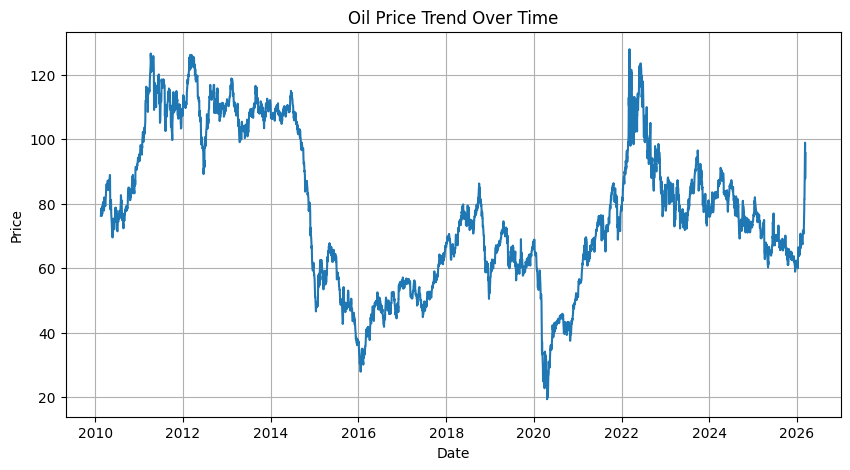

In [35]:
plt.figure(figsize = (10,5))
plt.plot(df_price['date'], df_price['brent_price'])
plt.title('Oil Price Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.show

#### Oil prices fluctuate over time, showing periods of increase and decline influenced by global economic and geopolitical events.

<hr style="height:15px;border:none;background:linear-gradient(to right, #00c9a7, #00bfff);">

### Yearly Price Change Analysis

This analysis measures how oil prices change from one year to another to identify periods of growth and decline.

In [36]:
yearly_price = df_price.groupby("year")["brent_price"].mean()

In [37]:
yearly_change = yearly_price.diff()

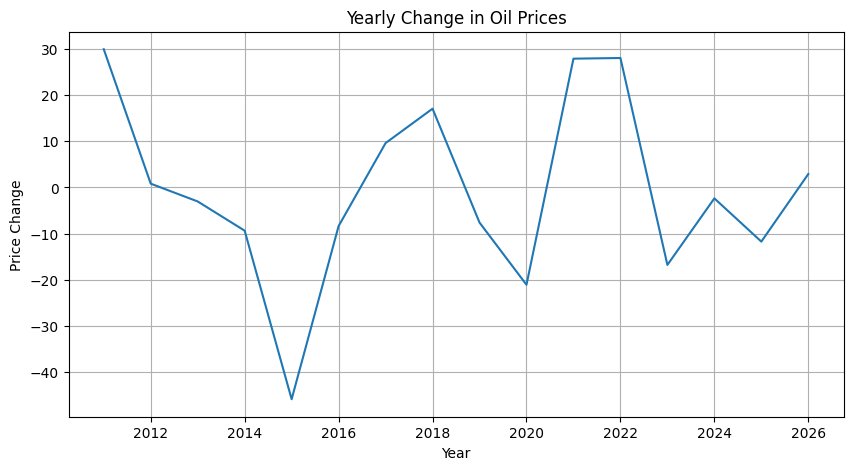

In [38]:
plt.figure(figsize=(10,5))
yearly_change.plot()
plt.title("Yearly Change in Oil Prices")
plt.xlabel("Year")
plt.ylabel("Price Change")
plt.grid(True)
plt.show()

#### Yearly price changes highlight periods of significant increase and decline, reflecting market instability during certain years.

<hr style="height:15px;border:none;background:linear-gradient(to right, #00c9a7, #00bfff);">

### Volatility Analysis

This analysis measures the volatility of oil prices using the standard deviation, which indicates how much prices fluctuate over time.

In [39]:
volatility = df_price["brent_price"].std()
volatility

np.float64(23.529261049288056)

#### The standard deviation of oil prices is approximately 23.529, indicating a relatively high level of price fluctuation over time.

<hr style="height:15px;border:none;background:linear-gradient(to right, #00c9a7, #00bfff);">

### Price Distribution Analysis

This analysis explores how oil prices are distributed across different ranges to understand typical price levels.

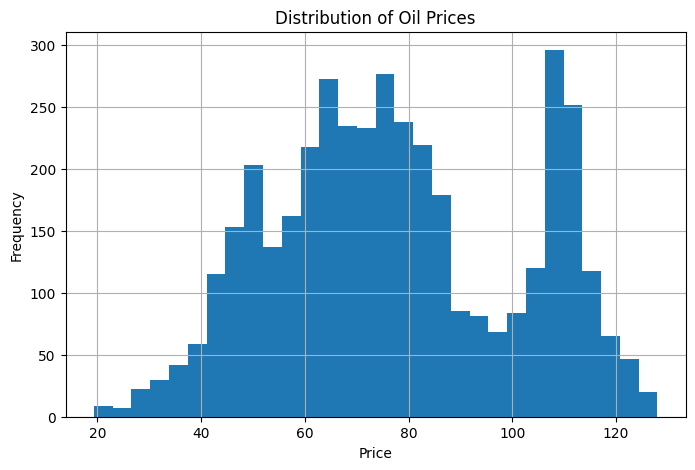

In [40]:
plt.figure(figsize=(8,5))
plt.hist(df_price["brent_price"], bins=30)
plt.title("Distribution of Oil Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

#### The distribution shows how frequently oil prices fall within certain ranges, indicating whether prices are typically low, medium, or high.

<hr style="height:15px;border:none;background:linear-gradient(to right, #00c9a7, #00bfff);">

### Moving Average Analysis

This analysis uses a moving average to smooth short-term fluctuations and reveal the overall trend of oil prices.

In [41]:
df_price["moving_avg"] = df_price["brent_price"].rolling(window=30).mean()

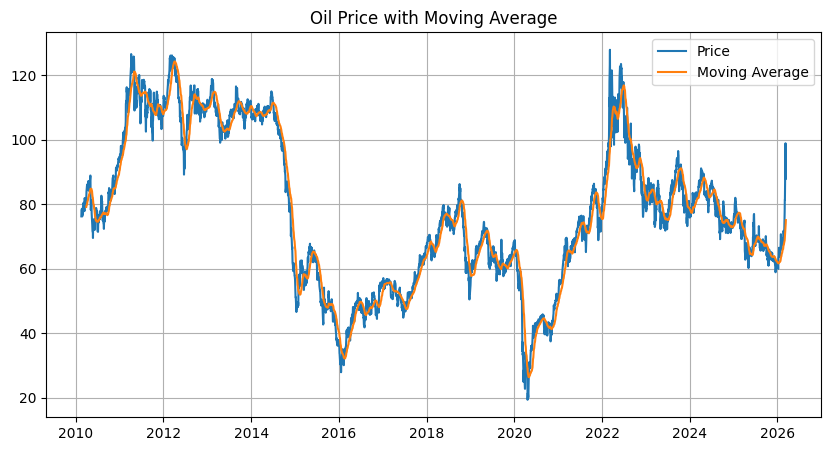

In [42]:
plt.figure(figsize=(10,5))
plt.plot(df_price["date"], df_price["brent_price"], label="Price")
plt.plot(df_price["date"], df_price["moving_avg"], label="Moving Average")
plt.legend()
plt.title("Oil Price with Moving Average")
plt.grid(True)
plt.show()

#### The moving average smooths short-term fluctuations and highlights the overall trend of oil prices over time.

<hr style="height:15px;border:none;background:linear-gradient(to right, #00c9a7, #00bfff);">

### Event Impact Analysis

This analysis examines how major geopolitical events affect oil prices over time.

In [43]:
df_price["event_type"].value_counts()

event_type
none                 4022
sanctions               6
conflict                4
war                     3
opec                    3
blockade                2
disaster                1
annexation              1
diplomatic_crisis       1
market_crash            1
blockage                1
energy_crisis           1
market_shift            1
Name: count, dtype: int64

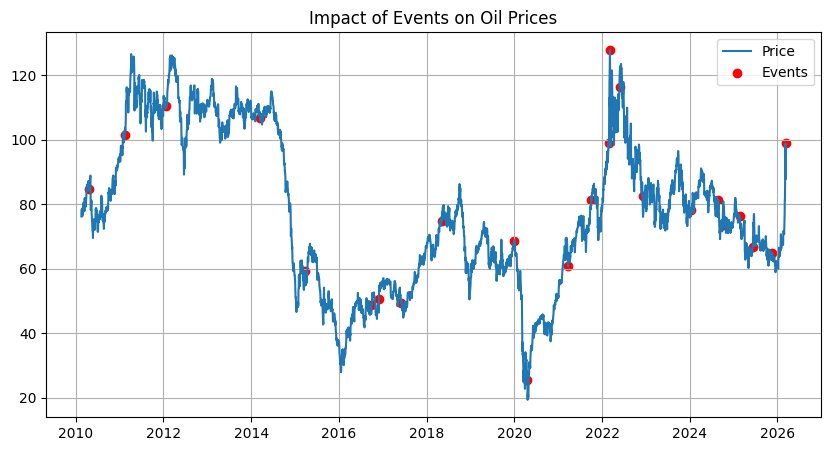

In [44]:
event_data = df_price[df_price["event_flag"] == 1]
plt.figure(figsize=(10,5))
plt.plot(df_price["date"], df_price["brent_price"], label="Price")
plt.scatter(event_data["date"], event_data["brent_price"], color="red", label="Events")
plt.legend()
plt.title("Impact of Events on Oil Prices")
plt.grid(True)
plt.show()

#### Significant changes in oil prices often coincide with major geopolitical events, indicating a strong relationship between global events and market behavior.

<hr style="height:15px;border:none;background:linear-gradient(to right, #00c9a7, #00bfff);">

### Top Oil Producing Countries

This analysis identifies the countries with the highest oil production based on average production over time.

In [45]:
df_no_world = df_clean[df_clean["Country"] != "World"]

In [46]:
top_countries = (
    df_no_world.groupby("Country")["Production"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

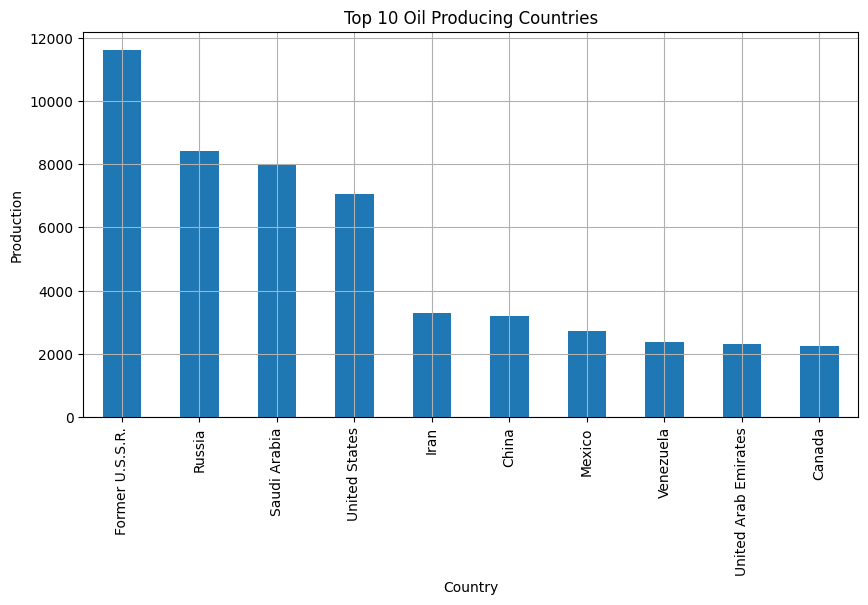

In [47]:
plt.figure(figsize=(10,5))
top_countries.plot(kind="bar")
plt.title("Top 10 Oil Producing Countries")
plt.ylabel("Production")
plt.grid(True)
plt.show()

#### The chart shows that a small number of countries dominate global oil production, with the top producers contributing a significant share of total output.

<hr style="height:15px;border:none;background:linear-gradient(to right, #00c9a7, #00bfff);">

### Global Production Trend

This analysis examines how total global oil production changes over time.

In [48]:
global_production = df_clean.groupby("Year")["Production"].sum()

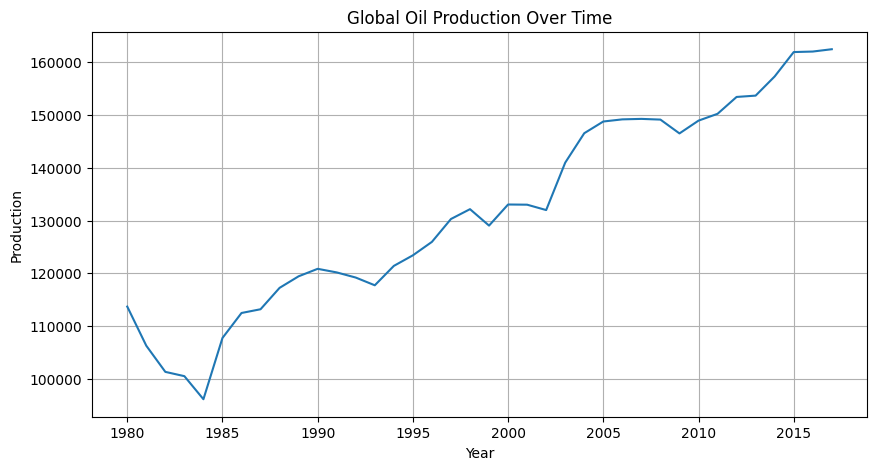

In [49]:
plt.figure(figsize=(10,5))
global_production.plot()
plt.title("Global Oil Production Over Time")
plt.xlabel("Year")
plt.ylabel("Production")
plt.grid(True)
plt.show()

#### Global oil production shows fluctuations over time, reflecting changes in supply, demand, and geopolitical factors.

<hr style="height:15px;border:none;background:linear-gradient(to right, #00c9a7, #00bfff);">

### Share of Global Production

This analysis shows the proportion of total oil production contributed by each country.

In [50]:
latest_year = df_clean["Year"].max()
latest_data = df_clean[df_clean["Year"] == latest_year]
latest_data = latest_data[latest_data["Country"] != "World"]
share = (
    latest_data.groupby("Country")["Production"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

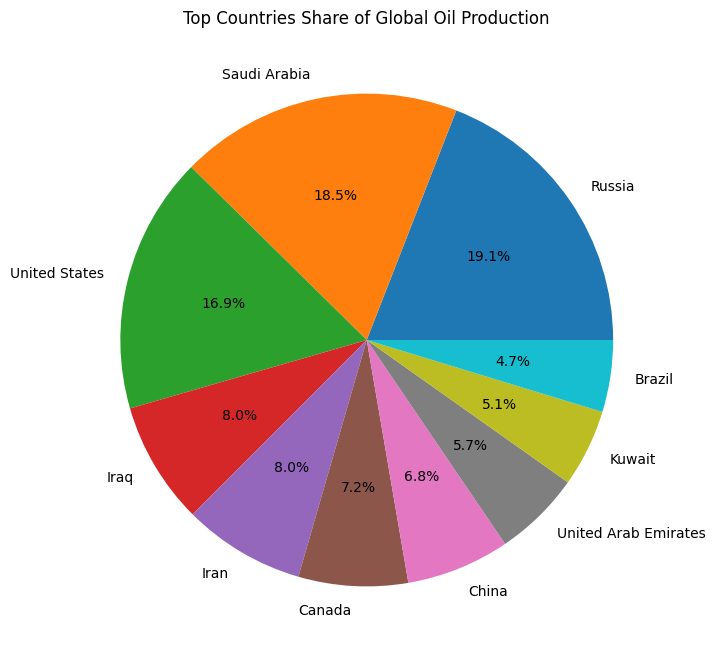

In [51]:
plt.figure(figsize=(8,8))
share.plot(kind='pie', autopct='%1.1f%%')
plt.title("Top Countries Share of Global Oil Production")
plt.ylabel("")  # يشيل كلمة Production على الجنب
plt.show()

#### Oil production is highly concentrated, with a small number of countries dominating global output. This highlights the strategic importance of major producers such as the United States, Saudi Arabia, and Russia in shaping the global oil market.

<hr style="height:15px;border:none;background:linear-gradient(to right, #00c9a7, #00bfff);">

### Yearly Change in Production

This analysis measures how global oil production changes from year to year.

In [52]:
production_change = global_production.diff()

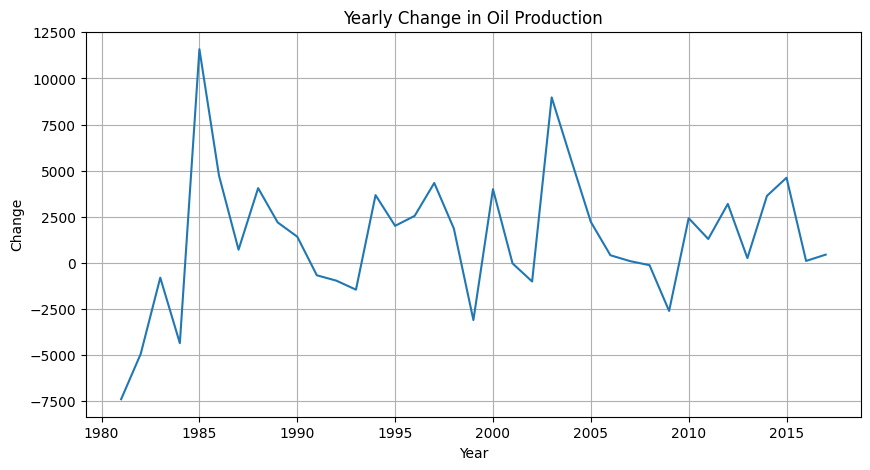

In [53]:
plt.figure(figsize=(10,5))
production_change.plot()
plt.title("Yearly Change in Oil Production")
plt.xlabel("Year")
plt.ylabel("Change")
plt.grid(True)
plt.show()

#### Yearly changes in production highlight periods of growth and decline in global oil supply.

<hr style="height:15px;border:none;background:linear-gradient(to right, #00c9a7, #00bfff);">

### Production Comparison Between Countries

This analysis compares oil production trends among major producing countries.

In [54]:
countries = ["Saudi Arabia", "United States", "Russia"]
comparison = df_clean[df_clean["Country"].isin(countries)]

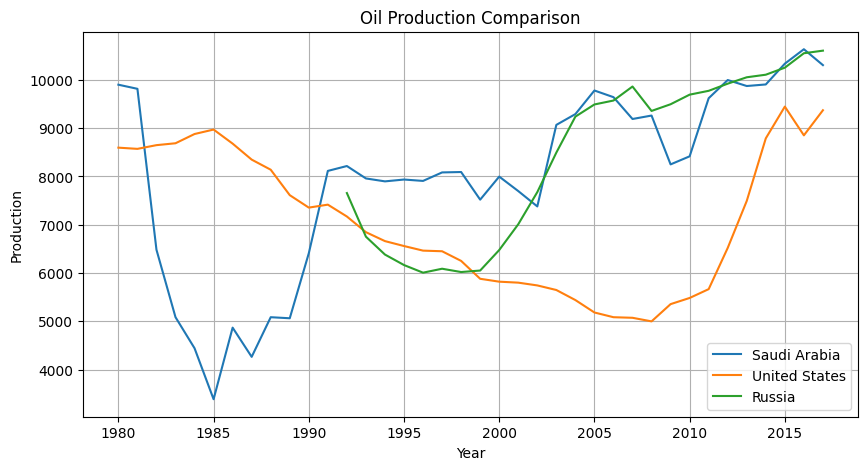

In [55]:
plt.figure(figsize=(10,5))
for c in countries:
    data = comparison[comparison["Country"] == c]
    plt.plot(data["Year"], data["Production"], label=c)
plt.legend()
plt.title("Oil Production Comparison")
plt.xlabel("Year")
plt.ylabel("Production")
plt.grid(True)
plt.show()

#### The comparison shows differences in production trends between major oil-producing countries, reflecting variations in production strategies and resources.

<hr style="height:15px;border:none;background:linear-gradient(to right, #00c9a7, #00bfff);">

### Combining Price and Production Data

In this section, the oil price data is combined with the oil production data using the year as a common factor. 
Since the price data is recorded daily and the production data is recorded yearly, the price data is first converted into yearly averages. 
This allows both datasets to be aligned and compared effectively for further analysis.

In [56]:
price_yearly = df_price.groupby("year")["brent_price"].mean().reset_index()

In [57]:
production_yearly = df_clean.groupby("Year")["Production"].sum().reset_index()

In [58]:
merged = pd.merge(
    price_yearly,
    production_yearly,
    left_on="year",
    right_on="Year",
    how="inner"
)

### Correlation Between Oil Price and Production

This analysis examines the relationship between global oil production and oil prices to determine whether changes in production levels influence market prices.

In [59]:
correlation = merged["brent_price"].corr(merged["Production"])
correlation

np.float64(-0.7776351584841701)

The correlation value is -0.78, indicating a strong negative relationship...

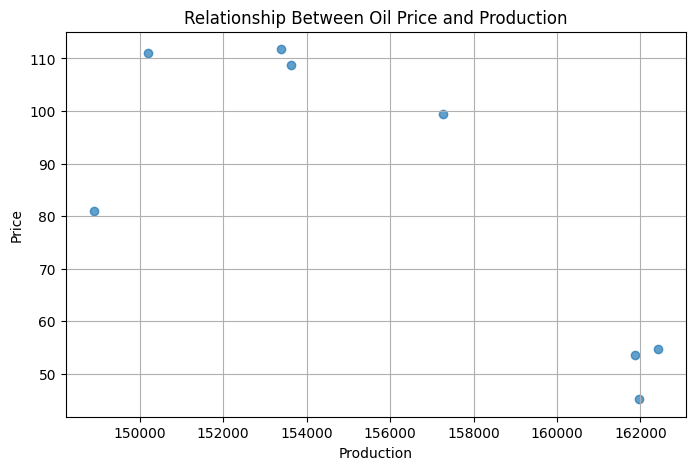

In [60]:
plt.figure(figsize=(8,5))
plt.scatter(merged["Production"], merged["brent_price"], alpha=0.7)
plt.title("Relationship Between Oil Price and Production")
plt.xlabel("Production")
plt.ylabel("Price")
plt.grid(True)
plt.show()

#### The scatter plot demonstrates a strong negative relationship between oil production and oil prices, indicating that as production increases, prices tend to decrease. This aligns with the principles of supply and demand in the oil market.

<hr style="height:15px;border:none;background:linear-gradient(to right, #00c9a7, #00bfff);">

## Conclusion

The analysis of the oil market reveals several important insights. Oil prices show significant fluctuations over time, influenced by economic conditions and geopolitical events. The volatility analysis confirms that the oil market is highly dynamic and subject to frequent changes.

From the production perspective, a small number of countries dominate global oil supply, highlighting a concentrated market structure. Production trends also vary over time, reflecting changes in global demand and supply strategies.

The combined analysis shows a strong negative correlation between oil production and oil prices, indicating that increases in production are generally associated with lower prices. This supports the fundamental economic principle of supply and demand.

However, it is important to note that oil prices are not driven by production alone. Other factors such as geopolitical events, economic conditions, and market sentiment also play a significant role.

Overall, this project demonstrates how data analysis can be used to understand complex market behavior and extract meaningful insights from real-world data.

In [61]:
import os
os.listdir()

['.ipynb_checkpoints',
 'Oil_country_production.csv',
 'oil_geopolitics_dataset_2010_2026.csv',
 'Oil_Market_Analysis.ipynb',
 'oil_project.zip']